<p>Python for Civil Engineers: Plotting Shear Force & Bending Moment Diagrams</p>
<img src="https://lh3.googleusercontent.com/d/1_23CpQNki00PVn4qU2dWfG9qMk_wZStE" width="400" />

<p>Reaction Calculation</p>

$$
L = 2+4+1+1 = 6\text{ m}
$$ 

$$
\sum M_B = 0
$$
$$
\implies 6R_E-1200-[100(6)]1=0
$$

$$
\boxed{R_E = 300\text{lb}}
$$

$$
\sum M_E = 0
$$
$$
\implies 6R_B+1200-[100(6)]5=0
$$

$$
\boxed{R_E = 300\text{lb}}
$$


In [3]:
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt

In [24]:
Adist = []
Asf = []
Abm = []

def sf_bm():
    # Distance & load
    L = 8 #ft
    W = 100 #plf
    M = 1200 #lb-ft

    # Support Reaction
    RB = 300 #lb
    RE = 300 #lb

    for i in np.linspace(0, L, L+1, dtype = int):
        Adist.append(i)

        # SF
        if i <= 6:
            sf = -W*i
        else:
            sf = -W*6
        if i>= 2:
            sf +=RB
        Asf.append(sf)

        # BM
        if i <=6:
            bm = -W*i*i*0.5
        else:
            bm = -W*6*(i-3)
        if i >= 2:
            bm += RB*(i-2) 
        if i >= 7:
            bm += M
        Abm.append(bm)
    return(Adist, Asf, Abm)

result = sf_bm()

print("Distance(ft) :", Adist)
print("Shear Force(lb) :", Asf)
print("Bending Moment(lb-ft) :", Abm)


Distance(ft) : [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8)]
Shear Force(lb) : [np.int64(0), np.int64(-100), np.int64(100), np.int64(0), np.int64(-100), np.int64(-200), np.int64(-300), -300, -300]
Bending Moment(lb-ft) : [np.float64(0.0), np.float64(-50.0), np.float64(-200.0), np.float64(-150.0), np.float64(-200.0), np.float64(-350.0), np.float64(-600.0), np.int64(300), np.int64(0)]


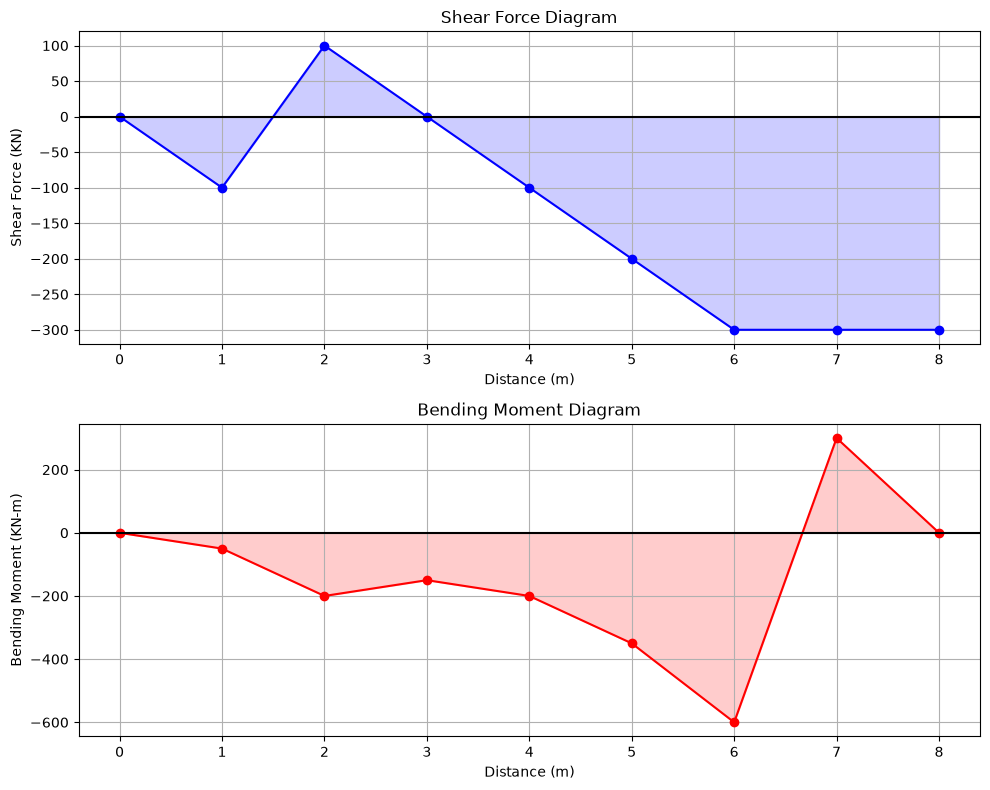

In [25]:
plt.figure(figsize=(10,8))

# SFD
plt.subplot(2,1,1)
plt.plot(Adist, Asf, color = 'blue', marker = 'o')
plt.fill_between(Adist, Asf, 0, color = 'blue', alpha = 0.2)
plt.axhline(0, color = 'black')
plt.xlabel("Distance (m)")
plt.ylabel("Shear Force (KN)")
plt.title("Shear Force Diagram")
plt.grid(True)

# BMD
plt.subplot(2,1,2)
plt.plot(Adist, Abm, color = 'red', marker = 'o')
plt.fill_between(Adist, Abm, 0, color = 'red', alpha = 0.2)
plt.axhline(0, color = 'black')
plt.xlabel("Distance (m)")
plt.ylabel("Bending Moment (KN-m)")
plt.title("Bending Moment Diagram")
plt.grid(True)

plt.tight_layout()
plt.show()
